# Visualizing UOT Data using PCA/UMAP
The UOT data is not intuitive to visualize. However, PCA/UMAP may help solve this issue. Thus, we'll import the cell line data and visualize it using PCA and UMAP to see if clustering makes intuitive sense.

## Imports

In [3]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [4]:
### Directories and Files ###
root = '../../../../../'
metadata_dir = root+'Generated Data/Single-to-single/sc_uot_ramani/Metadata/maxnorm_total_mass.csv'
save_dir = root+'Generated Data/Single-to-single/sc_uot_ramani/Clustering'

In [5]:
### Imports ###
import sys
import numpy as np
import pandas as pd
from umap import UMAP
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
### Pre-importing metadata ###
metadata_df = pd.read_csv(metadata_dir, index_col=0)
metadata_df

,cell_name,total_mass_1mb_87,total_mass_1mb_95,total_mass_1mb_98,total_mass_2mb_85,total_mass_4mb_85,cell_line
0,cell231_HAP1_,1941.566416,938.503117,360.011112,516.899966,120.767018,HAP1
1,cell447_HAP1_,571.521891,495.144885,289.556840,136.625814,34.354590,HAP1
2,cell470_HAP1_,586.339846,490.376493,275.947577,138.433529,45.520736,HAP1
3,cell312_HAP1_,1108.256462,741.299690,328.747511,265.206067,69.050665,HAP1
4,cell29_HAP1_,1675.821060,883.559129,355.572255,435.640040,113.949017,HAP1
...,...,...,...,...,...,...,...
615,cell63_HeLa_,1577.132727,831.020976,352.527350,403.021046,110.950627,HeLa
616,cell54_HeLa_,1417.336487,833.285618,352.084282,354.485148,86.897894,HeLa
617,cell549_K562_,1388.605358,838.461384,350.797609,338.676013,90.951444,K562
618,cell219_HeLa_,1573.195954,869.111472,362.481811,391.248261,97.703535,HeLa


## Helper Functions

### Data Handling

In [ ]:
def load_ot_results_matrix(
        folder: str, 
        res: int, 
        thres: int, 
        reg_m: float,
        count: int=20,
        seed: int=42
        ) -> pd.DataFrame:
    
    '''
        Loads OT results for cell lines data.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        res : int
            Resolution used for analysis.
        thres : int
            Threshold used for analysis.
        reg_m : float
            Unbalanced parameter used.
        count : int
            Number of cells used per cell line for analysis.
            Default = 20.
        seed : int
            Seed used to select data.
            Default = 42.

        Returns
        -------
        ot_df_matrix : pd.DataFrame
            OT results in a pairwise dataframe.
    '''
    # File
    file = f"{folder}/CELL_LINES_unbalanced_reg_m={reg_m}_cluster_{res}mb_{thres}_{count}_seed={seed}.csv"

    # Importing file
    ot_df_matrix = pd.read_csv(file, index_col=0)
    return ot_df_matrix

### Visualizing Data

In [8]:
def generate_clustering(
        data : np.ndarray,
        cell_lines : list[str],
        reg_m : float,
        ax,
        kind : str = "PCA"
        ):
    '''
        Draws clustering of the data to the provided Axes object
        using either PCA of UMAP

        Parameters
        ----------
        data : np.ndarray
            OT data in ndarray form.
        cell_lines : list[str]
            List of cell lines corresponding to the cell order in
            the data.
        reg_m : float
            Used reg_m value for subtitle.
        ax
            Axes object to parse figure to
        kind : str
            Kind of clustering to use (PCA or UMAP).
            Default = "PCA"
    '''
    # PCA or UMAP
    if kind == "PCA":
        vec = PCA(n_components=2).fit_transform(data)
        xlab = "PC 1"
        ylab= "PC 2"
    elif kind == "UMAP":
        vec = UMAP(n_components=2).fit_transform(data)
        xlab = "UMAP 1"
        ylab= "UMAP 2"
    else:
        raise ValueError(f"Unknown clustering kind: {kind}")

    # Figure
    sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_lines, ax=ax, s=15, linewidth=0)
    handles, labels = ax.get_legend_handles_labels()
    labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
    ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=1)
    ax.set_title(f"reg_m={reg_m}")
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    return

## Loading Data

In [9]:
### Loading data for all reg_m values ###
reg_m_list = [1, 10, 50]
data_list = []

for reg_m in reg_m_list:
    data_list.append(load_ot_results_matrix(save_dir, 4, 85, reg_m, 38, 42).to_numpy())

In [10]:
### Extracting cell lines ###
cell_subset = load_ot_results_matrix(save_dir, 4, 85, 50, 38, 42).index
cell_lines = []
for cell in cell_subset:
    cell_lines.append(cell.split("_")[1])

## PCA

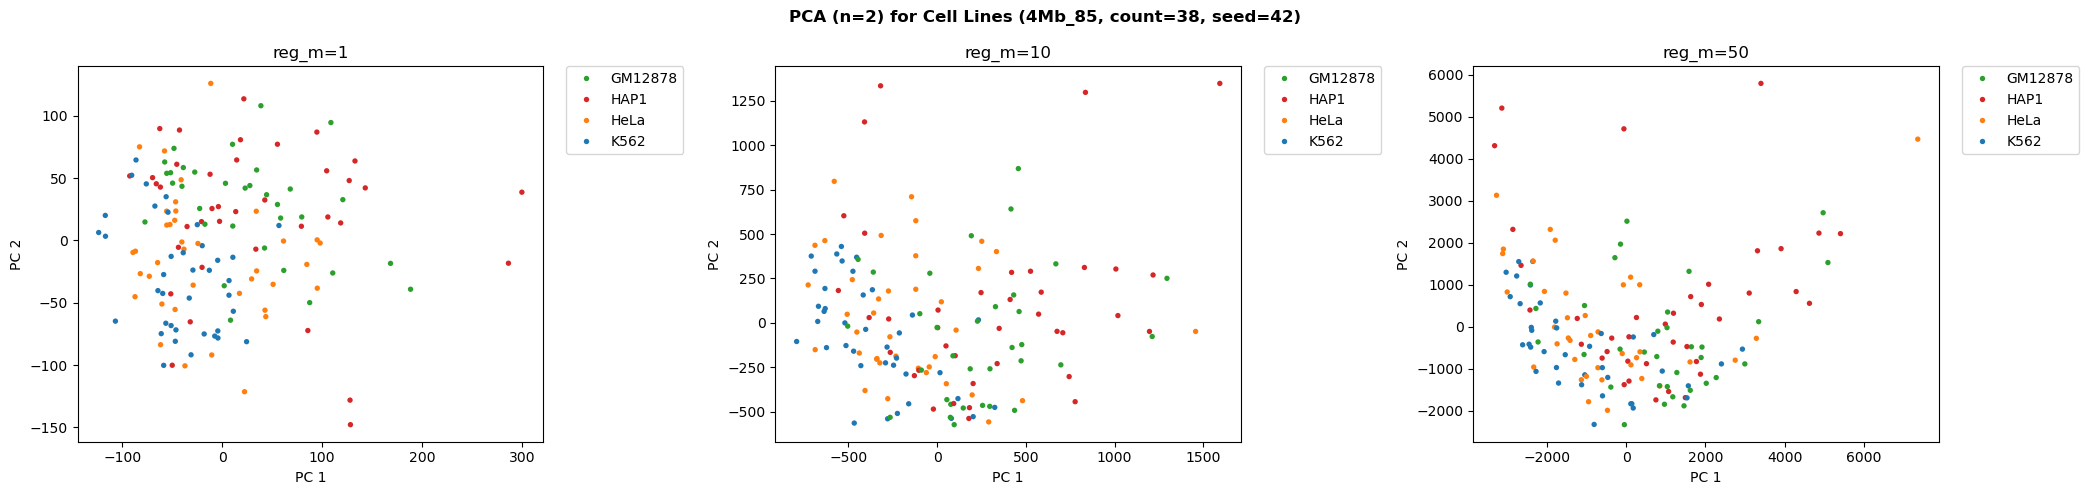

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

for data, reg_m, ax in zip(data_list, reg_m_list, axes):
    generate_clustering(data, cell_lines, reg_m, ax)

plt.suptitle("PCA (n=2) for Cell Lines (4Mb_85, count=38, seed=42)", fontweight="bold")
plt.tight_layout()

## UMAP

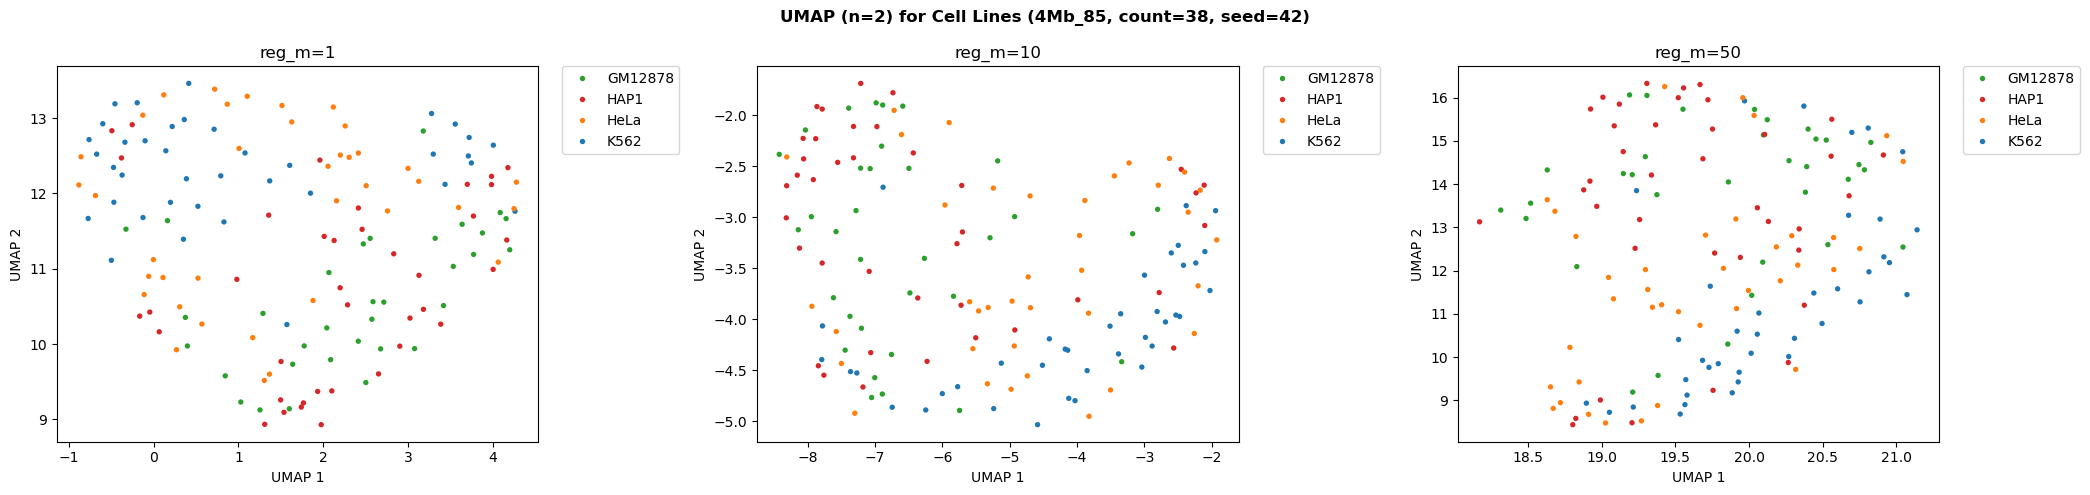

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

for data, reg_m, ax in zip(data_list, reg_m_list, axes):
    generate_clustering(data, cell_lines, reg_m, ax, "UMAP")

plt.suptitle("UMAP (n=2) for Cell Lines (4Mb_85, count=38, seed=42)", fontweight="bold")
plt.tight_layout()

Both PCA and UMAP still don't show any defined clustering. At most, in the UMAP, you can indeed see that K526 and HeLa cluster somewhat close to one another, like the cluster map suggested.